## Visuaize Bond Cleavage and BDE of the ground truth molecules formed.

[*] Loading dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt...
[*] Hunting for 7 UNIQUE molecules with cleavage events...

[*] Visualizing Graph Index 0 | CE: 35.0 eV | Total Cuts: 2
[*] SMILES: Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1


/tmp/ipykernel_1832848/3654187431.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load(data_path)


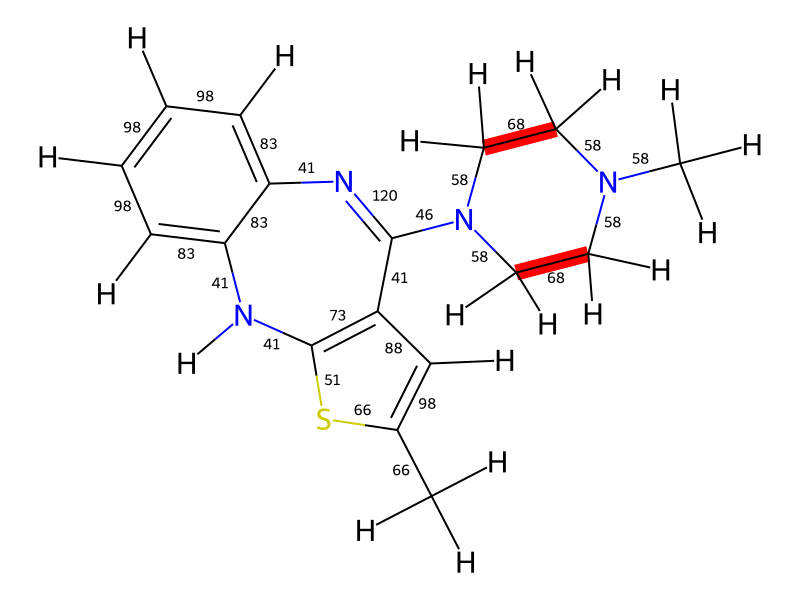


[*] Visualizing Graph Index 72 | CE: 35.0 eV | Total Cuts: 15
[*] SMILES: CCCCC(C)C(OC(=O)CC(CC(=O)O)C(=O)O)C(CC(C)CC(O)CCCCCCC(O)C(C)N)OC(=O)CC(CC(=O)O)C(=O)O


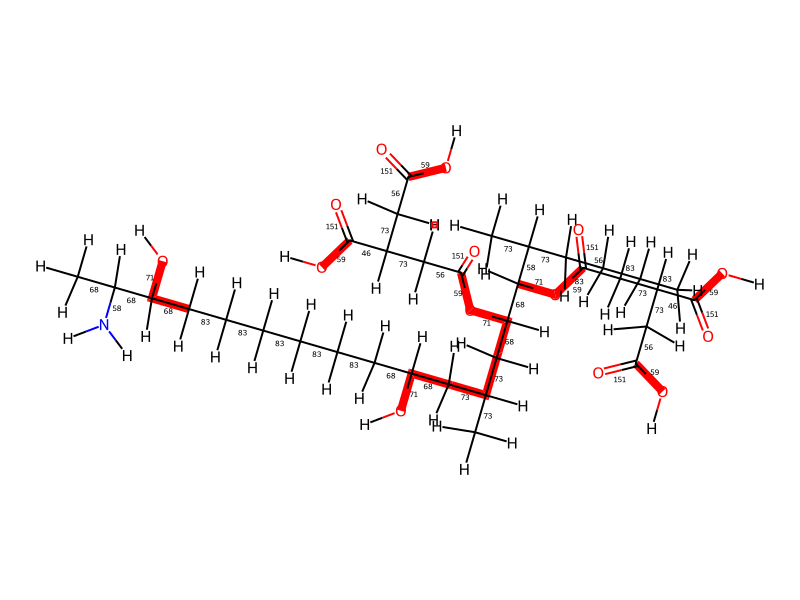


[*] Visualizing Graph Index 96 | CE: 35.0 eV | Total Cuts: 9
[*] SMILES: CC1OC(OC2C(O)C(OCCc3ccc(O)c(O)c3)OC(CO)C2OC(=O)C=Cc2ccc(O)c(O)c2)C(O)C(O)C1O


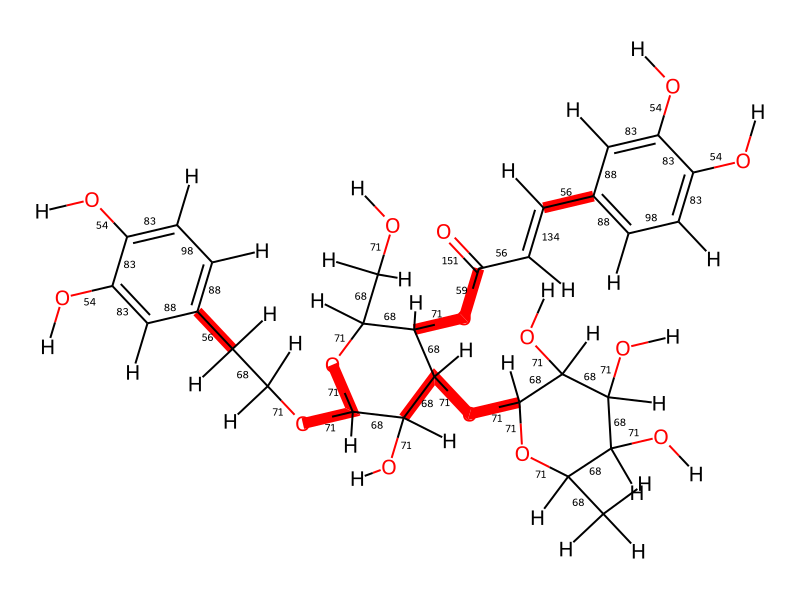


[*] Visualizing Graph Index 116 | CE: 35.0 eV | Total Cuts: 4
[*] SMILES: C(CC=Nc1ccccc1)=Nc1ccccc1


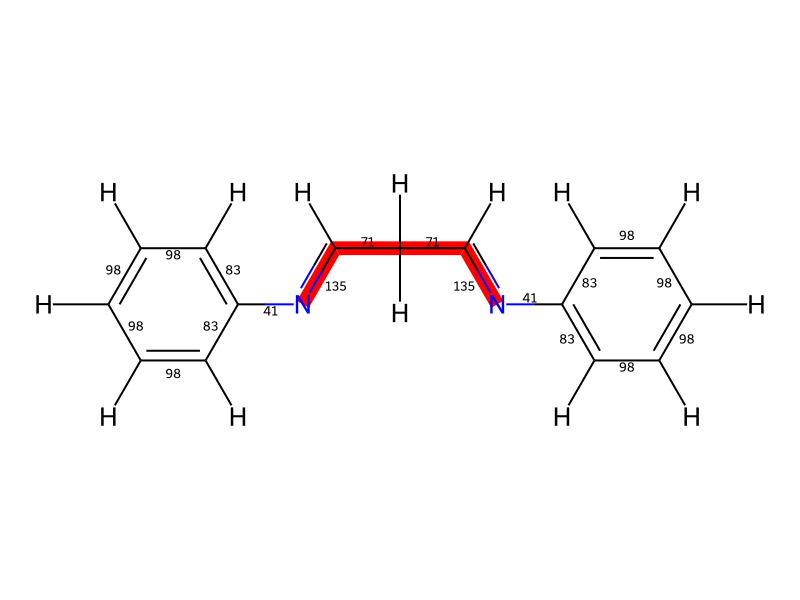


[*] Visualizing Graph Index 119 | CE: 35.0 eV | Total Cuts: 1
[*] SMILES: C#CC1(O)C(CO)OC(n2ccc(N)nc2=O)C1O


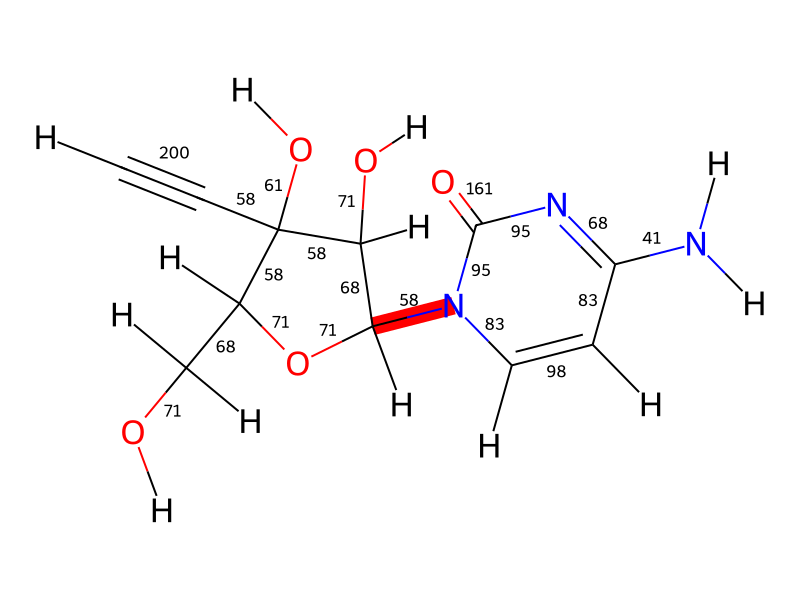


[*] Visualizing Graph Index 128 | CE: 35.0 eV | Total Cuts: 8
[*] SMILES: CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl


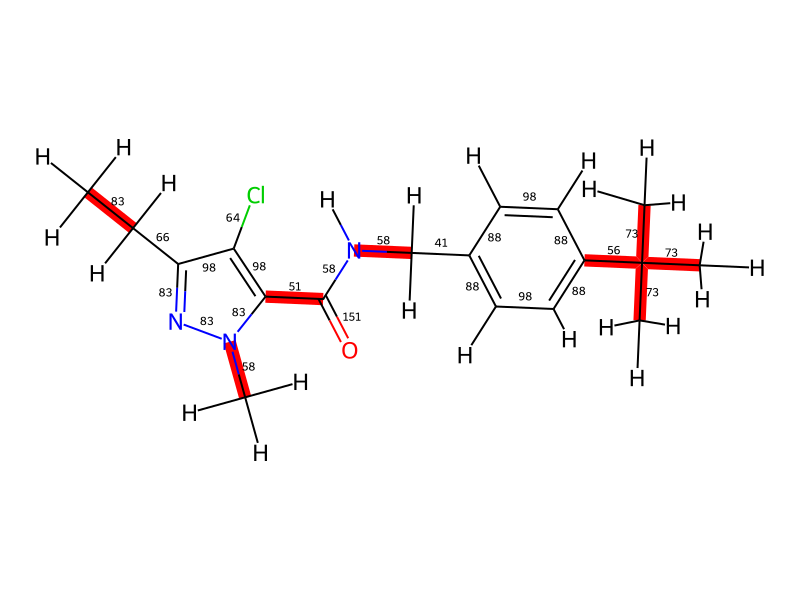


[*] Visualizing Graph Index 143 | CE: 35.0 eV | Total Cuts: 2
[*] SMILES: CNC(=O)Oc1cc(C)c([S+](C)[O-])c(C)c1


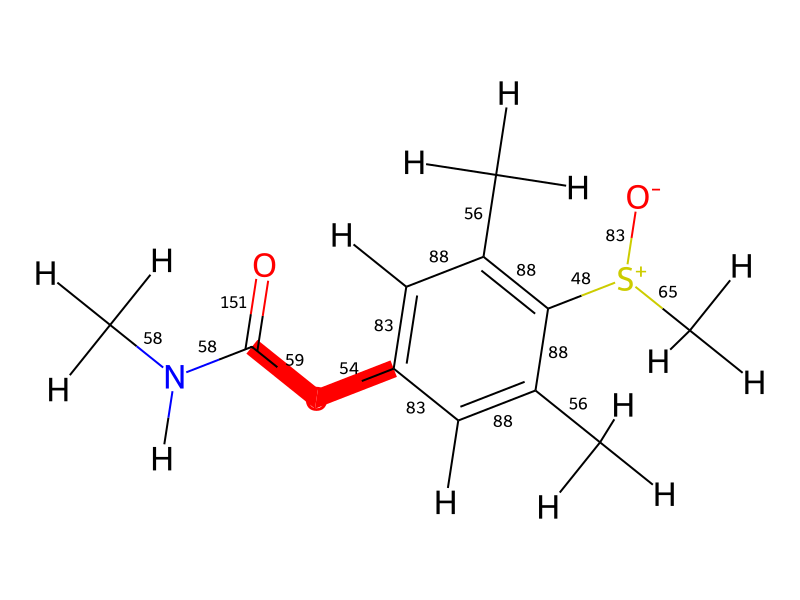

In [6]:
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import Image, display

# ==========================================
# 1. VISUALIZATION FUNCTION 
# ==========================================
def visualize_ground_truth_inline(pyg_data, graph_idx=0):
    """
    Renders a 2D molecule from a PyG Data object directly in a Jupyter Notebook.
    Forces a solid white background, labels BDEs, and highlights cuts in RED.
    """
    smiles = getattr(pyg_data, 'smiles', None)
    if not smiles: return

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) 
    Chem.rdDepictor.Compute2DCoords(mol)

    edge_index = pyg_data.edge_index.numpy()
    edge_attr = pyg_data.edge_attr.numpy()
    y_cleavage = pyg_data.y_cleavage.numpy()

    highlight_bonds = []
    bond_colors = {}

    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        bond_idx = bond.GetIdx()

        match_idx = np.where((edge_index[0] == u) & (edge_index[1] == v))[0]
        
        if len(match_idx) > 0:
            tensor_idx = match_idx[0]
            bde_val = edge_attr[tensor_idx, 0] 
            is_cut = y_cleavage[tensor_idx]    
            
            bond.SetProp("bondNote", f"{bde_val:.0f}")
            
            if is_cut == 1.0:
                highlight_bonds.append(bond_idx)
                bond_colors[bond_idx] = (1.0, 0.0, 0.0) # Bright Red

    # Solid White Canvas
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(800, 600)
    opts = drawer.drawOptions()
    opts.addStereoAnnotation = False
    opts.bondNoteFontSize = 14
    opts.clearBackground = True 
    opts.setBackgroundColour((1.0, 1.0, 1.0, 1.0)) 

    drawer.DrawMolecule(mol, highlightAtoms=[], highlightBonds=highlight_bonds, highlightBondColors=bond_colors)
    drawer.FinishDrawing()
    
    img_bytes = drawer.GetDrawingText()
    
    ce_val = edge_attr[0, 1] if len(edge_attr) > 0 else "N/A"
    print(f"\n[*] Visualizing Graph Index {graph_idx} | CE: {ce_val} eV | Total Cuts: {int(y_cleavage.sum() / 2)}")
    print(f"[*] SMILES: {smiles}")
    display(Image(data=img_bytes, format='png'))

# ==========================================
# 2. SMART HUNTING EXECUTION LOOP
# ==========================================
data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt"
print(f"[*] Loading dataset from {data_path}...")
dataset = torch.load(data_path)

seen_smiles = set()
graphs_shown = 0
target_graphs = 7

print(f"[*] Hunting for {target_graphs} UNIQUE molecules with cleavage events...")

for i, data in enumerate(dataset):
    smiles = getattr(data, 'smiles', '')
    
    # Logic: It must have a cut bond AND we must not have drawn it yet
    if data.y_cleavage.sum().item() > 0 and smiles not in seen_smiles:
        visualize_ground_truth_inline(data, graph_idx=i)
        seen_smiles.add(smiles)
        graphs_shown += 1
        
    if graphs_shown >= target_graphs:
        break

if graphs_shown == 0:
    print("[-] Could not find any graphs with cleavages.")

In [3]:
import torch
data = torch.load("/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt")

unique_smiles = set()
for graph in data:
    unique_smiles.add(graph.smiles)

print(f"Total Graphs: {len(data)}")
print(f"Unique Molecules: {len(unique_smiles)}")

/tmp/ipykernel_1127965/3492802897.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gy

Total Graphs: 260706
Unique Molecules: 30101


[*] Loading merged configurations and initializing DESAF-Net Architecture...
[*] Loading trained Phase 1 weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase1_best.pt...


/tmp/ipykernel_4007467/4027402932.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(WEIGHTS_PATH, map_location=device)


[*] Loading dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt...
[*] Loading pre-computed Phase 1 graphs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt into RAM...
[+] Loaded 260706 graphs.

[*] Scanning for structurally unique molecules...

[+] Found 5 unique molecule indices: [0, 72, 96, 116, 119, 128, 143, 181, 209, 228]

[*] Visualizing Inference for Graph Index 0
[*] SMILES: Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


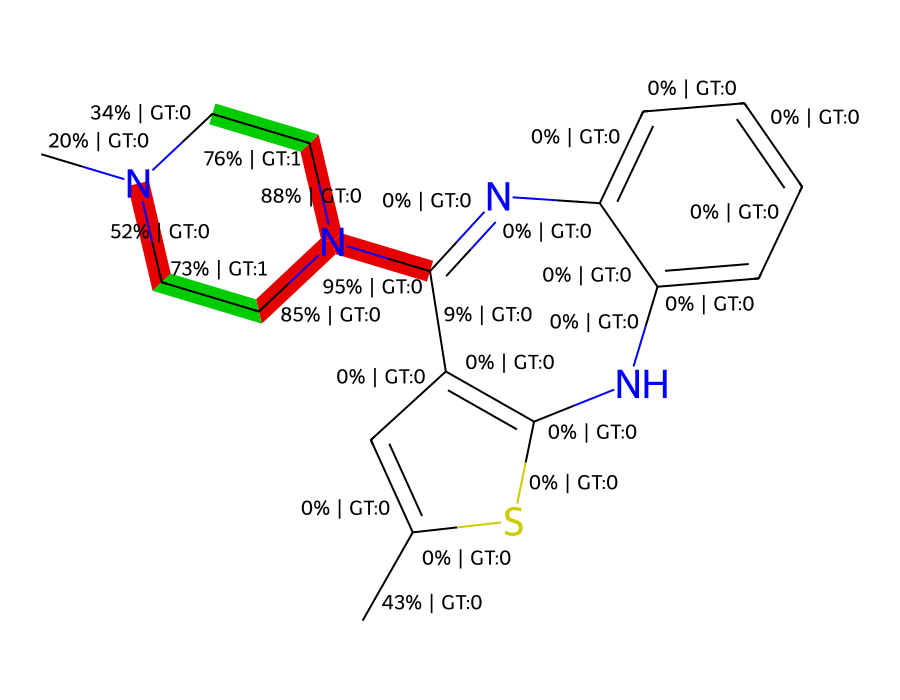


[*] Visualizing Inference for Graph Index 72
[*] SMILES: CCCCC(C)C(OC(=O)CC(CC(=O)O)C(=O)O)C(CC(C)CC(O)CCCCCCC(O)C(C)N)OC(=O)CC(CC(=O)O)C(=O)O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


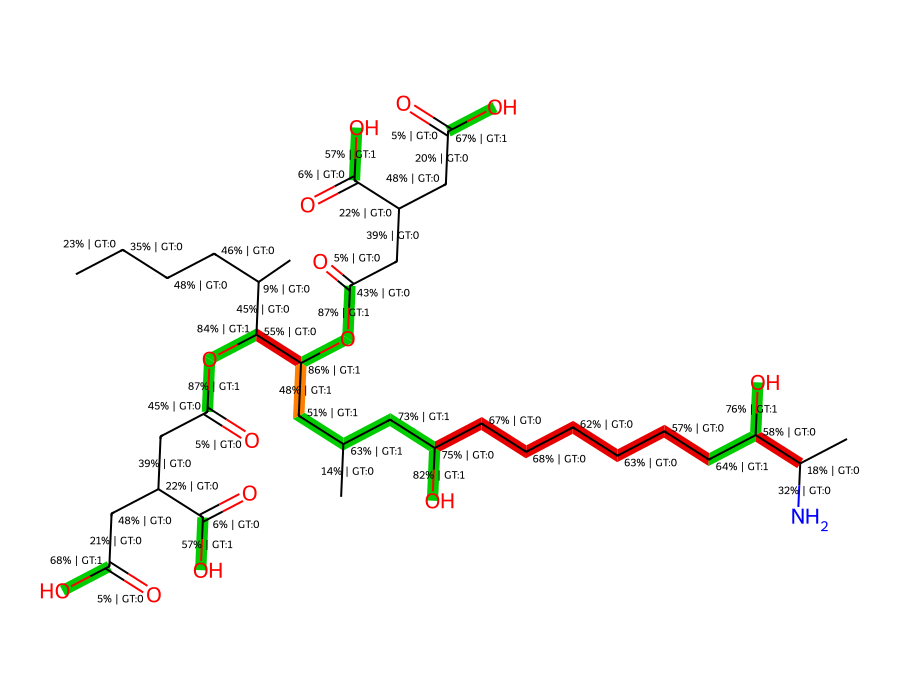


[*] Visualizing Inference for Graph Index 96
[*] SMILES: CC1OC(OC2C(O)C(OCCc3ccc(O)c(O)c3)OC(CO)C2OC(=O)C=Cc2ccc(O)c(O)c2)C(O)C(O)C1O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


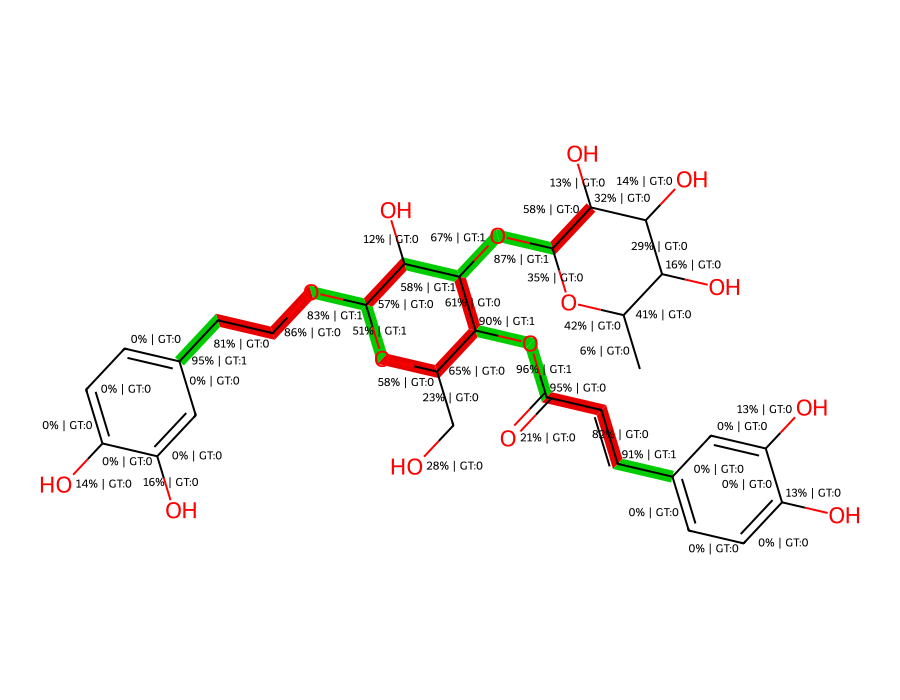


[*] Visualizing Inference for Graph Index 116
[*] SMILES: C(CC=Nc1ccccc1)=Nc1ccccc1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


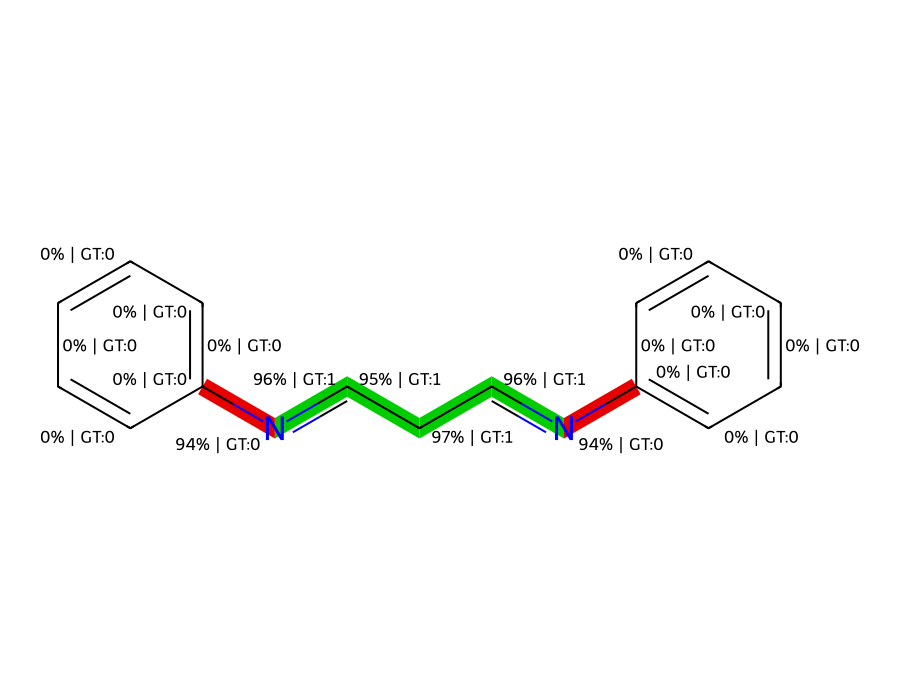


[*] Visualizing Inference for Graph Index 119
[*] SMILES: C#CC1(O)C(CO)OC(n2ccc(N)nc2=O)C1O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


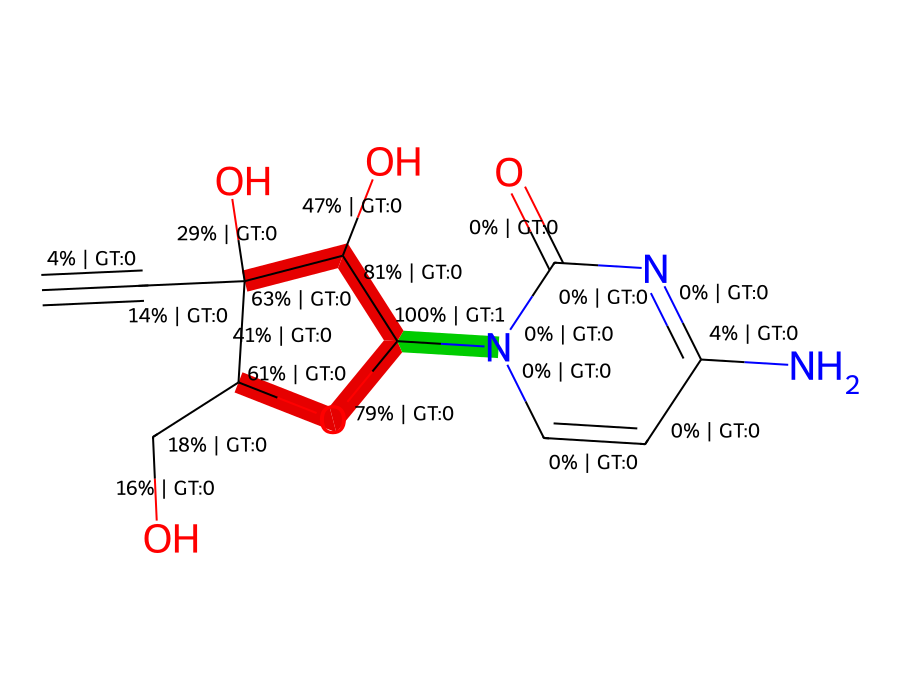


[*] Visualizing Inference for Graph Index 128
[*] SMILES: CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


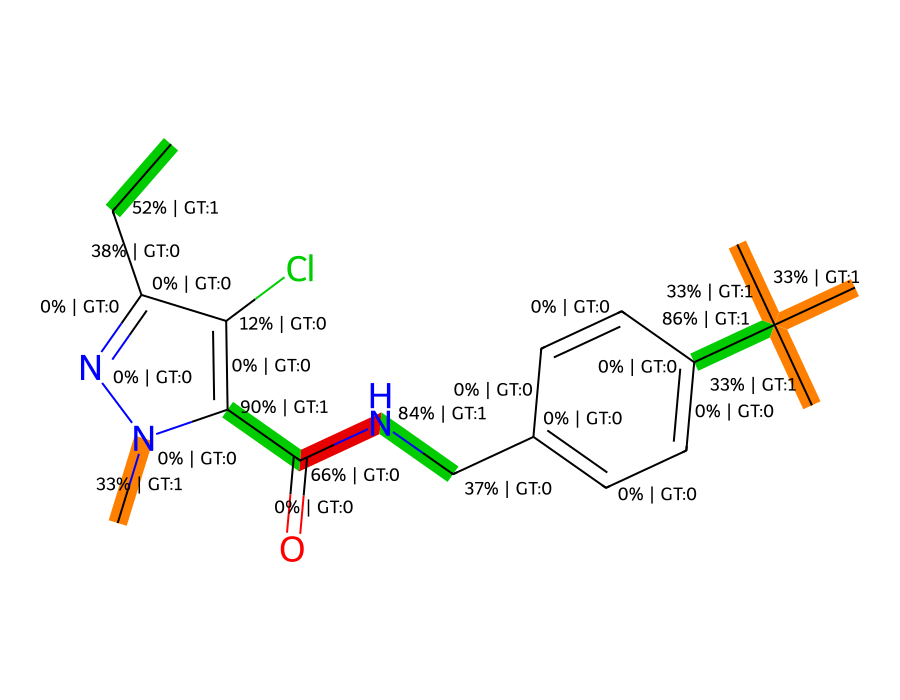


[*] Visualizing Inference for Graph Index 143
[*] SMILES: CNC(=O)Oc1cc(C)c([S+](C)[O-])c(C)c1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


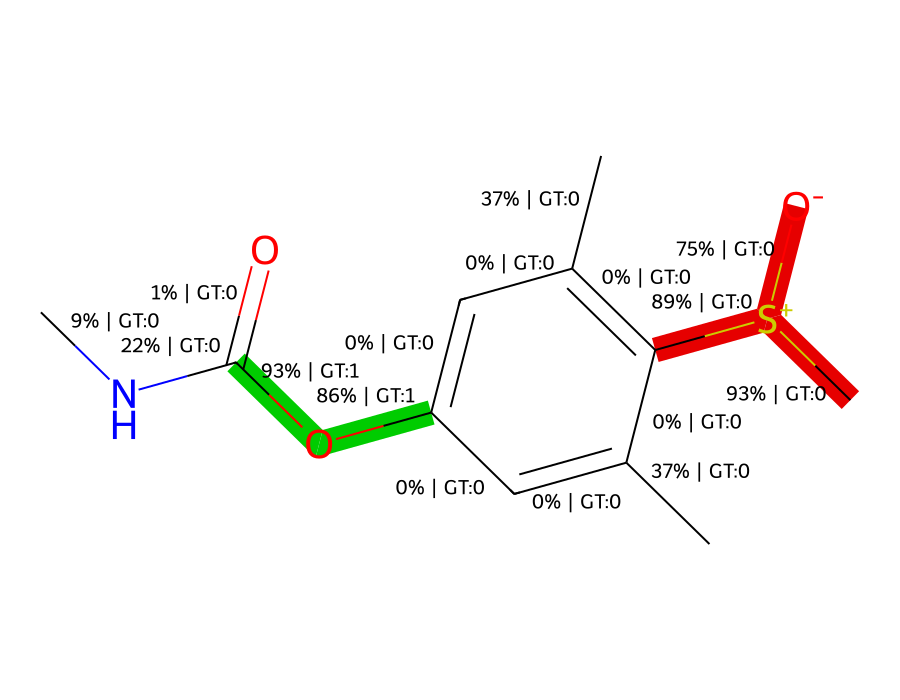


[*] Visualizing Inference for Graph Index 181
[*] SMILES: CC(=O)c1c(O)c(C)c(O)c2c1OC1=CC(=O)C(C(C)=NCC(=O)N3CCc4ccccc4C3)C(=O)C12C
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


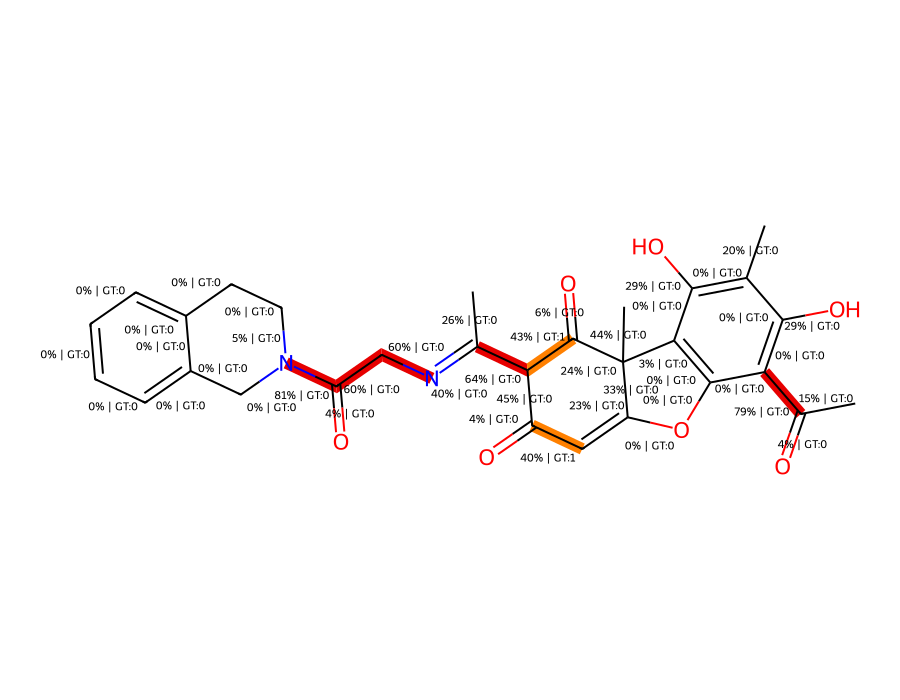


[*] Visualizing Inference for Graph Index 209
[*] SMILES: CCC(C)C1NC(=O)C(C(C)CC)NC1=O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


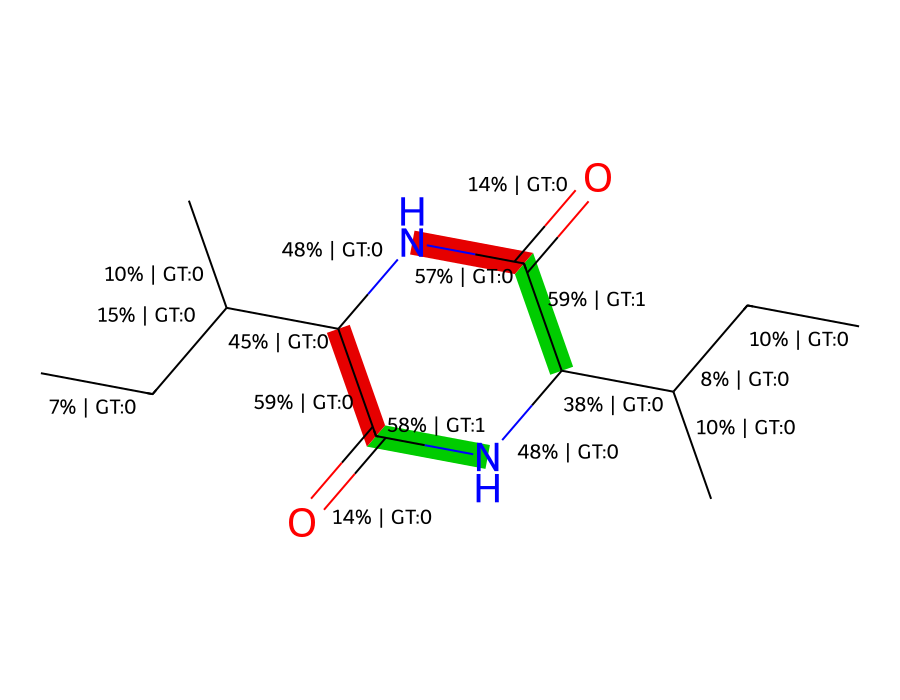


[*] Visualizing Inference for Graph Index 228
[*] SMILES: Cn1ncc2c(NCCO)nc(Nc3ccc(F)c(F)c3)nc21
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


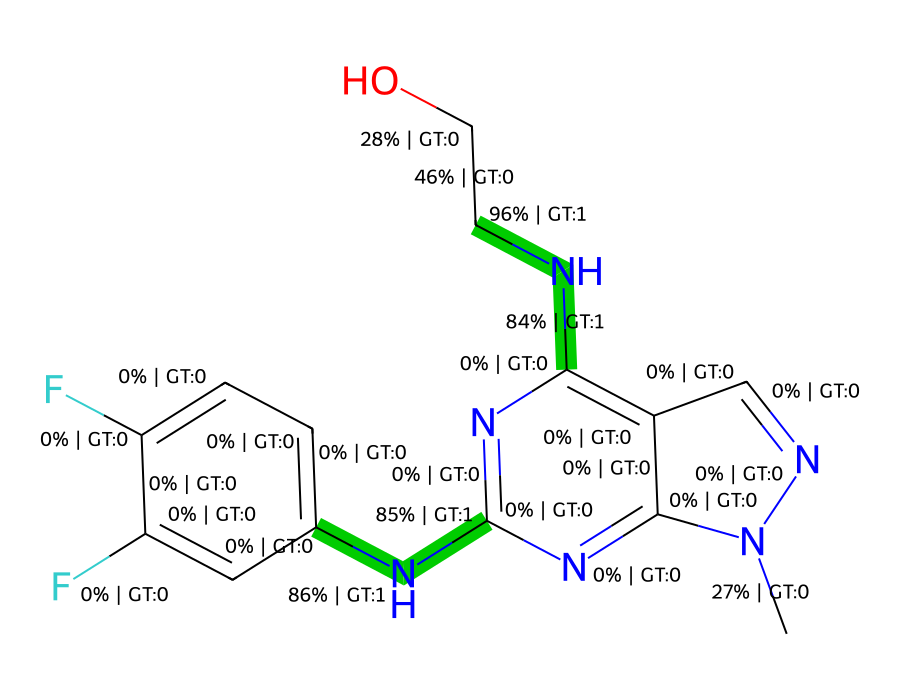

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm  # JUPYTER FIX: Beautiful HTML progress bars
import yaml
import os
import sys
import wandb
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import Image, display
import numpy as np

# --- SETUP PATHS ---
cwd = Path.cwd().parent
# Make sure your notebook is running in the directory ABOVE 'data_loaders' and 'model'
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))

try:
    from data_loader import Phase1EdgeDataset, phase1_collate_fn
    from phase1_model import DESAFNet
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")
    # JUPYTER FIX: Prevent kernel death by raising instead of sys.exit()
    raise e 

def load_and_merge_configs(template_path="template.yml", custom_path="demo.yml"):
    """Merges the base template with the custom demo configurations."""
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

def visualize_model_predictions(model, dataset, graph_idx, threshold=0.5):
    """
    Runs inference on a single graph and visualizes the model's confidence 
    vs. the ground truth labels on the 2D molecule.
    """
    device = next(model.parameters()).device
    model.eval()
    
    # 1. Retrieve the raw PyG graph and reconstruct the RDKit molecule
    pyg_data = dataset.graphs[graph_idx]
    smiles = getattr(pyg_data, 'smiles', None)
    if not smiles: 
        print(f"[-] No SMILES found for graph {graph_idx}")
        return
        
    mol = Chem.MolFromSmiles(smiles)
    Chem.rdDepictor.Compute2DCoords(mol)
    
    # 2. Isolate the item and create a batch of size 1 using our custom collator
    mf_item = dataset[graph_idx]
    if mf_item is None:
        print("[-] Graphormer padding failed for this molecule. Skipping.")
        return
        
    batch = phase1_collate_fn([mf_item])
    batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
    
    # 3. Run Inference
    with torch.no_grad():
        logits = model.forward_phase1(batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        
    y_true = batch['y_cleavage'].cpu().numpy()
    edge_index = batch['edge_index'].cpu().numpy()
    
    # 4. Map Predictions to RDKit Bonds
    highlight_bonds = []
    bond_colors = {}
    
    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        bond_idx = bond.GetIdx()

        # Find where this specific undirected RDKit bond matches our directed edge_index
        match_idx = np.where((edge_index[0] == u) & (edge_index[1] == v))[0]
        
        if len(match_idx) > 0:
            tensor_idx = match_idx[0]
            pred_prob = probs[tensor_idx]
            gt_label = int(y_true[tensor_idx])
            
            # Annotate the bond with Prediction % and Ground Truth
            bond.SetProp("bondNote", f"{pred_prob*100:.0f}% | GT:{gt_label}")
            
            # Color Coding Logic based on the threshold
            if pred_prob >= threshold:
                highlight_bonds.append(bond_idx)
                if gt_label == 1:
                    # True Positive: Model confidently predicted a real cut (Green)
                    bond_colors[bond_idx] = (0.0, 0.8, 0.0) 
                else:
                    # False Positive: Model confidently hallucinated a cut (Red)
                    bond_colors[bond_idx] = (0.9, 0.0, 0.0)
            else:
                if gt_label == 1:
                    # False Negative: Model missed a real cut (Orange)
                    highlight_bonds.append(bond_idx)
                    bond_colors[bond_idx] = (1.0, 0.5, 0.0)

    # 5. Draw the Molecule
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(900, 700)
    opts = drawer.drawOptions()
    opts.addStereoAnnotation = False
    opts.bondNoteFontSize = 14
    opts.clearBackground = True 
    opts.setBackgroundColour((1.0, 1.0, 1.0, 1.0)) 

    drawer.DrawMolecule(mol, highlightAtoms=[], highlightBonds=highlight_bonds, highlightBondColors=bond_colors)
    drawer.FinishDrawing()
    
    print(f"\n[*] Visualizing Inference for Graph Index {graph_idx}")
    print(f"[*] SMILES: {smiles}")
    print("[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut")
    
    # Jupyter specific display command
    display(Image(data=drawer.GetDrawingText(), format='png'))

# ==========================================
# JUPYTER EXECUTION CONFIGURATION
# ==========================================
# Adjust these paths to match your actual setup
DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt"
WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase1_best.pt"
TEMPLATE_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
CUSTOM_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Merged Configs and Initialize Model
print("[*] Loading merged configurations and initializing DESAF-Net Architecture...")
full_config = load_and_merge_configs(TEMPLATE_CONFIG_PATH, CUSTOM_CONFIG_PATH)
model = DESAFNet(model_config=full_config['model']).to(device)

# 2. Load Weights
print(f"[*] Loading trained Phase 1 weights from {WEIGHTS_PATH}...")
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint, strict=False)

# 3. Load Dataset (into RAM)
print(f"[*] Loading dataset from {DATA_PATH}...")
dataset = Phase1EdgeDataset(DATA_PATH)

# ==========================================
# SMART MOLECULE EXPLORER
# ==========================================
print("\n[*] Scanning for structurally unique molecules...")
unique_smiles = set()
fascinating_indices = []

# Scan until we find 5 completely different molecules that actually break
for i, data in enumerate(dataset.graphs):
    if data.y_cleavage.sum().item() > 1: # Must have at least 2 cuts
        smiles = getattr(data, 'smiles', None)
        if smiles and smiles not in unique_smiles:
            unique_smiles.add(smiles)
            fascinating_indices.append(i)
            
    if len(fascinating_indices) >= 10:
        break

print(f"\n[+] Found 5 unique molecule indices: {fascinating_indices}")

# CHANGE THIS to any of the numbers printed above!
target_idx = fascinating_indices[1] 

for i in fascinating_indices:
    # Render
    visualize_model_predictions(model, dataset, graph_idx=i, threshold=0.5)

In [1]:
import torch
import yaml
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader
from rdkit import Chem
from rdkit.Chem import Draw
from io import BytesIO
from PIL import Image
from scipy.sparse.csgraph import connected_components
from torch_geometric.utils import to_scipy_sparse_matrix
from torch_scatter import scatter_sum
from pathlib import Path

# --- SETUP PATHS ---
cwd = Path.cwd().parent
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))
sys.path.insert(0, os.path.join(str(cwd), 'model', 'flare'))

# Adjust these paths to your environment
from phase2_dataloader import Phase2EdgeDataset, phase2_collate_fn
from phase2_model_new import DESAFNet

def load_and_merge_configs(template_path="template.yml", custom_path="demo.yml"):
    with open(template_path, 'r', encoding='utf-8') as f: 
        config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: 
            custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: 
                config[section] = subdict
    return config


def evaluate_and_visualize(model_weights_path, data_path, template_config, custom_config, target_indices=[0], tolerance=0.05):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Using device: {device}")

    # ==========================================
    # 1. LOAD MODEL AND WEIGHTS
    # ==========================================
    config = load_and_merge_configs(template_config, custom_config)
    model = DESAFNet(model_config=config['model']).to(device)
    
    if not os.path.exists(model_weights_path):
        print(f"[-] Weights not found at {model_weights_path}")
        sys.exit(1)
        
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.eval()
    print(f"[+] Loaded Phase 2 weights: {model_weights_path}")

    dataset = Phase2EdgeDataset(processed_graphs_path=data_path)

    # ==========================================
    # 2. THE MULTI-PLOT LOOP
    # ==========================================
    for target_idx in target_indices:
        print(f"\n{'-'*50}")
        print(f"[*] Processing Molecule Index: {target_idx}")
        
        raw_graph = dataset.graphs[target_idx]
        smiles = raw_graph.smiles
        print(f"[*] SMILES: {smiles}")
        
        val_loader = DataLoader(
            [dataset[target_idx]], batch_size=1, shuffle=False, collate_fn=phase2_collate_fn
        )
        batch = next(iter(val_loader))
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        # ==========================================
        # 3. DETERMINISTIC DUAL-HEAD INFERENCE PASS
        # ==========================================
        with torch.no_grad():
            X_base = model.graph_encoder({'gf_v2_data': batch})
            X = X_base[0][:, 1:, :] if isinstance(X_base, tuple) else X_base[:, 1:, :]
            
            true_nodes = (batch['x'][0, :, 0] != 0).sum().item()
            X_flat = X[0, :true_nodes, :]
            raw_features_flat = batch['x'][0, :true_nodes, :]
            edge_index = batch['edge_index']
            edge_attr = batch['edge_attr_physics']
            
            # --- Dual Head Predictions ---
            break_logits = model.edge_head(X_flat, edge_index, edge_attr).squeeze()
            break_probs = torch.sigmoid(break_logits)
            
            h_logits = model.h_routing_head(X_flat, edge_index, edge_attr)
            h_probs = torch.softmax(h_logits, dim=-1)
            
            cut_actions = (break_probs > 0.5).long()
            h_actions = torch.argmax(h_probs, dim=-1)
            
            surviving_mask = (cut_actions == 0)
            surviving_edge_index = edge_index[:, surviving_mask]
            
            adj_sparse = to_scipy_sparse_matrix(surviving_edge_index, num_nodes=true_nodes)
            _, fragment_labels = connected_components(adj_sparse, directed=False)
            fragment_labels = torch.tensor(fragment_labels, device=device, dtype=torch.long)
            
            raw_atomic_vals = raw_features_flat[:, 0]
            atomic_numbers = torch.clamp(raw_atomic_vals - 1, min=0, max=119).long()
            raw_hydrogens = raw_features_flat[:, 4]
            implicit_hydrogens = torch.clamp(raw_hydrogens - 2050, min=0).float()
            
            base_masses = model.mass_lookup[atomic_numbers]
            node_masses = base_masses + (implicit_hydrogens * 1.007825)
            
            # --- Physical Hydrogen Routing ---
            H_MASS = 1.007825
            routing_shifts = (h_actions.float() - 2.0) * H_MASS 
            active_shifts = routing_shifts * cut_actions.float()
            
            u, v = edge_index[0], edge_index[1]
            directed_mask = (u < v).float()
            final_shifts = active_shifts * directed_mask
            
            node_masses = node_masses.clone() 
            node_masses.scatter_add_(0, u, final_shifts)
            node_masses.scatter_add_(0, v, -final_shifts)
            
            fragment_masses = scatter_sum(node_masses, fragment_labels, dim=0)
            theoretical_mzs = fragment_masses + 1.007276

        # ==========================================
        # 4. DUAL-LAYOUT VISUALIZATION
        # ==========================================
        mol = Chem.MolFromSmiles(smiles)
        unique_frags = torch.unique(fragment_labels).cpu().numpy()
        
        cmap_bonds = LinearSegmentedColormap.from_list("prob", ["#d3d3d3", "#ff0000"])
        bond_colors = {}
        severed_bonds_list = []
        
        for i in range(edge_index.shape[1]):
            u, v = edge_index[0, i].item(), edge_index[1, i].item()
            bond = mol.GetBondBetweenAtoms(u, v)
            if bond is not None:
                prob = break_probs[i].item()
                bond_colors[bond.GetIdx()] = cmap_bonds(prob)[:3]
                if cut_actions[i].item() == 1:
                    severed_bonds_list.append(bond.GetIdx())

        cmap_frags = plt.get_cmap('tab10')
        frag_colors = {frag_id: cmap_frags(i % 10) for i, frag_id in enumerate(unique_frags)}
        atom_colors = {atom_idx: frag_colors[frag_id][:3] for atom_idx, frag_id in enumerate(fragment_labels.cpu().numpy())}

        fig = plt.figure(figsize=(16, 6))
        
        # Left Plot: Molecular Graph
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.axis('off')
        ax1.set_title(f"Mol {target_idx} | Cleavage Probabilities (Red > 50%)\nGenerated {len(unique_frags)} Fragments", fontsize=14)
        
        drawer = Draw.rdMolDraw2D.MolDraw2DCairo(600, 600)
        drawer.DrawMolecule(
            mol, 
            highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors,
            highlightBonds=list(bond_colors.keys()), highlightBondColors=bond_colors
        )
        drawer.FinishDrawing()
        img = Image.open(BytesIO(drawer.GetDrawingText()))
        ax1.imshow(img)

        # Right Plot: Spectral Alignment
        ax2 = fig.add_subplot(1, 2, 2)
        ax2.set_title(f"Ground Truth MS/MS vs Theoretical Fragments", fontsize=14)
        ax2.set_xlabel("m/z (Daltons)", fontsize=12)
        ax2.set_ylabel("Relative Intensity", fontsize=12)
        
        actual_peaks = batch['peaks'][0][~batch['peak_mask'][0]]
        exp_mzs = actual_peaks[:, 0] * 1000.0 
        exp_ints = actual_peaks[:, 1].clone()
        if len(exp_mzs) > 0:
            exp_ints[torch.argmax(exp_mzs)] = 0.0 
        
        markerline, stemlines, baseline = ax2.stem(
            exp_mzs.cpu().numpy(), exp_ints.cpu().numpy(), 
            linefmt='grey', markerfmt='D', basefmt=' '
        )
        plt.setp(stemlines, 'linewidth', 2, 'alpha', 0.4)
        plt.setp(markerline, 'color', 'grey', 'alpha', 0.4)

        max_target_int = torch.max(exp_ints).item() if len(exp_ints) > 0 else 1.0
        theoretical_mzs_np = theoretical_mzs.cpu().numpy()
        
        for i, frag_id in enumerate(unique_frags):
            frag_mass = theoretical_mzs_np[i]
            frag_color = frag_colors[frag_id]
            
            diffs = torch.abs(torch.tensor(frag_mass) - exp_mzs)
            matched = (diffs <= tolerance).any().item()
            
            plot_intensity = max_target_int if matched else (max_target_int * 0.15)
            linewidth = 3 if matched else 1
            
            markerline, stemlines, baseline = ax2.stem(
                [frag_mass], [plot_intensity], linefmt='-', markerfmt='o', basefmt=' '
            )
            plt.setp(stemlines, 'color', frag_color, 'linewidth', linewidth)
            plt.setp(markerline, 'color', frag_color)
            
            if matched:
                ax2.annotate(f"{frag_mass:.2f}", (frag_mass, plot_intensity), 
                             textcoords="offset points", xytext=(0,10), ha='center', color=frag_color, fontweight='bold')

        plt.tight_layout()
        save_name = f"desaf_phase2_diagnostic_mol_{target_idx}.png"
        plt.savefig(save_name, dpi=300)
        print(f"[+] Saved diagnostic image: {save_name}")
        
        plt.close(fig)

if __name__ == '__main__':
    # Define your paths here
    WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/phase2_run_2/desaf_phase2_best.pt"
    DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt"
    
    TEMPLATE_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml" 
    CUSTOM_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    
    TARGET_MOLECULES = [50, 100, 150, 200, 250, 300, 325, 400, 500, 1200, 1600] 
    
    evaluate_and_visualize(
        model_weights_path=WEIGHTS_PATH, 
        data_path=DATA_PATH, 
        template_config=TEMPLATE_CONFIG, 
        custom_config=CUSTOM_CONFIG,
        target_indices=TARGET_MOLECULES
    )

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cud

[*] Using device: cuda


/tmp/ipykernel_2899634/2229852254.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path, map_location=device))
/data/nas-g

[+] Loaded Phase 2 weights: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/phase2_run_2/desaf_phase2_best.pt
[*] Loading Phase 2 graphs (with spectra) from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt...
[+] Loaded 260706 pairs.

--------------------------------------------------
[*] Processing Molecule Index: 50
[*] SMILES: Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1
[+] Saved diagnostic image: desaf_phase2_diagnostic_mol_50.png

--------------------------------------------------
[*] Processing Molecule Index: 100
[*] SMILES: CC1OC(OC2C(O)C(OCCc3ccc(O)c(O)c3)OC(CO)C2OC(=O)C=Cc2ccc(O)c(O)c2)C(O)C(O)C1O
[+] Saved diagnostic image: desaf_phase2_diagnostic_mol_100.png

--------------------------------------------------
[*] Processing Molecule Index: 150
[*] SMILES: CNC(=O)Oc1cc(C)c([S+](C)[O-])c(C)c1
[+] Saved diagnostic image: desaf_phase2_diagnostic_mol_150.png

--------------------------------------------------
[*] Proc